In [2]:
import pandas as pd 
import matplotlib.pyplot as plt


In [3]:
financial=pd.read_csv("../cleaned_data/financial_long.csv")
cash=pd.read_csv("../cleaned_data/cashflow_long.csv")
balance=pd.read_csv("../cleaned_data/balance_long.csv")

In [4]:
print(financial.head())
print(cash.head())
print(balance.head())

                                   Metric        Year         Value
0             Tax Effect Of Unusual Items  2023-12-31  0.000000e+00
1                      Tax Rate For Calcs  2023-12-31  2.100000e-01
2                       Normalized EBITDA  2023-12-31  1.479600e+10
3                     Total Unusual Items  2023-12-31  0.000000e+00
4  Total Unusual Items Excluding Goodwill  2023-12-31  0.000000e+00
                      Metric        Year         Value
0             Free Cash Flow  2023-12-31  4.357000e+09
1          Repayment Of Debt  2023-12-31 -1.815000e+09
2           Issuance Of Debt  2023-12-31  3.931000e+09
3  Issuance Of Capital Stock  2023-12-31           NaN
4        Capital Expenditure  2023-12-31 -8.899000e+09
                   Metric        Year         Value
0  Treasury Shares Number  2023-12-31  0.000000e+00
1  Ordinary Shares Number  2023-12-31  3.185000e+09
2            Share Issued  2023-12-31  3.185000e+09
3                Net Debt  2023-12-31           NaN
4 

In [5]:
revenue=financial[financial["Metric"]=="Total Revenue"]
print(revenue)

            Metric        Year         Value
45   Total Revenue  2023-12-31  9.677300e+10
92   Total Revenue  2022-12-31  8.146200e+10
139  Total Revenue  2021-12-31  5.382300e+10
186  Total Revenue  2020-12-31  3.153600e+10


In [6]:
ebitda=financial[financial["Metric"]=="EBITDA"]

print(ebitda)

     Metric        Year         Value
8    EBITDA  2023-12-31  1.479600e+10
55   EBITDA  2022-12-31  1.765700e+10
102  EBITDA  2021-12-31  9.625000e+09
149  EBITDA  2020-12-31  4.224000e+09


In [7]:
net_income=financial[financial["Metric"]=="Net Income"]
print(net_income)

         Metric        Year         Value
26   Net Income  2023-12-31  1.499900e+10
73   Net Income  2022-12-31  1.258300e+10
120  Net Income  2021-12-31  5.524000e+09
167  Net Income  2020-12-31  7.210000e+08


In [8]:
cash = pd.read_csv("../cleaned_data/cashflow_cleaned.csv")

print(cash.head())

                      Metric    2023-12-31    2022-12-31    2021-12-31  \
0             Free Cash Flow  4.357000e+09  7.552000e+09  3.483000e+09   
1          Repayment Of Debt -1.815000e+09 -3.866000e+09 -1.461500e+10   
2           Issuance Of Debt  3.931000e+09  0.000000e+00  8.883000e+09   
3  Issuance Of Capital Stock           NaN  0.000000e+00  0.000000e+00   
4        Capital Expenditure -8.899000e+09 -7.172000e+09 -8.014000e+09   

     2020-12-31  
0  2.701000e+09  
1 -1.220100e+10  
2  9.713000e+09  
3  1.226900e+10  
4 -3.242000e+09  


In [9]:
cashflow_long = pd.melt(
    cash,
    id_vars=["Metric"],
    var_name="Year",
    value_name="Value"
)

print(cashflow_long.head())
cashflow_long.to_csv(
    "../cleaned_data/cashflow_long.csv",
    index=False
)

                      Metric        Year         Value
0             Free Cash Flow  2023-12-31  4.357000e+09
1          Repayment Of Debt  2023-12-31 -1.815000e+09
2           Issuance Of Debt  2023-12-31  3.931000e+09
3  Issuance Of Capital Stock  2023-12-31           NaN
4        Capital Expenditure  2023-12-31 -8.899000e+09


In [32]:
fcf = cash[
    cash["Metric"]=="Free Cash Flow"
]
fcf = pd.melt(
    fcf,
    id_vars=["Metric"],
    var_name="Year",
    value_name="Value"
)

print(fcf)

           Metric        Year         Value
0  Free Cash Flow  2023-12-31  4.357000e+09
1  Free Cash Flow  2022-12-31  7.552000e+09
2  Free Cash Flow  2021-12-31  3.483000e+09
3  Free Cash Flow  2020-12-31  2.701000e+09


In [33]:
fcf_long = fcf.sort_values("Year").reset_index(drop=True)

fcf_long["YoY Growth %"] = (
    fcf_long["Value"].pct_change()
) * 100

print(fcf_long)

           Metric        Year         Value  YoY Growth %
0  Free Cash Flow  2020-12-31  2.701000e+09           NaN
1  Free Cash Flow  2021-12-31  3.483000e+09     28.952240
2  Free Cash Flow  2022-12-31  7.552000e+09    116.824577
3  Free Cash Flow  2023-12-31  4.357000e+09    -42.306674


In [34]:
debt = balance[
    balance["Metric"]=="Total Debt"
]

print(debt)

         Metric        Year         Value
4    Total Debt  2023-12-31  9.573000e+09
88   Total Debt  2022-12-31  5.748000e+09
172  Total Debt  2021-12-31  8.873000e+09
256  Total Debt  2020-12-31  1.327900e+10


In [35]:
kpi_table = pd.concat([

    revenue,

    ebitda,

    net_income,

    fcf,

    debt,

])

print(kpi_table)

             Metric        Year         Value  YoY Growth %
186   Total Revenue  2020-12-31  3.153600e+10           NaN
139   Total Revenue  2021-12-31  5.382300e+10     70.671613
92    Total Revenue  2022-12-31  8.146200e+10     51.351653
45    Total Revenue  2023-12-31  9.677300e+10     18.795267
149          EBITDA  2020-12-31  4.224000e+09           NaN
102          EBITDA  2021-12-31  9.625000e+09    127.864583
55           EBITDA  2022-12-31  1.765700e+10     83.449351
8            EBITDA  2023-12-31  1.479600e+10    -16.203206
167      Net Income  2020-12-31  7.210000e+08           NaN
120      Net Income  2021-12-31  5.524000e+09    666.158114
73       Net Income  2022-12-31  1.258300e+10    127.787835
26       Net Income  2023-12-31  1.499900e+10     19.200509
0    Free Cash Flow  2023-12-31  4.357000e+09           NaN
1    Free Cash Flow  2022-12-31  7.552000e+09           NaN
2    Free Cash Flow  2021-12-31  3.483000e+09           NaN
3    Free Cash Flow  2020-12-31  2.70100

In [36]:
kpi_table.to_csv("../cleaned_data/kpi_table.csv",index=False)


In [37]:
revenue=revenue.sort_values("Year")
revenue["YoY Growth %"]=(
    revenue["Value"].pct_change()
)*100

print(revenue)

            Metric        Year         Value  YoY Growth %
186  Total Revenue  2020-12-31  3.153600e+10           NaN
139  Total Revenue  2021-12-31  5.382300e+10     70.671613
92   Total Revenue  2022-12-31  8.146200e+10     51.351653
45   Total Revenue  2023-12-31  9.677300e+10     18.795267


In [38]:
ebitda=ebitda.sort_values("Year")
ebitda["YoY Growth %"]=(
    ebitda["Value"].pct_change()
)*100
print(ebitda)


     Metric        Year         Value  YoY Growth %
149  EBITDA  2020-12-31  4.224000e+09           NaN
102  EBITDA  2021-12-31  9.625000e+09    127.864583
55   EBITDA  2022-12-31  1.765700e+10     83.449351
8    EBITDA  2023-12-31  1.479600e+10    -16.203206


In [21]:
net_income=net_income.sort_values("Year")
net_income["YoY Growth %"]=(
    net_income["Value"].pct_change()
)*100

print(net_income)


         Metric        Year         Value  YoY Growth %
167  Net Income  2020-12-31  7.210000e+08           NaN
120  Net Income  2021-12-31  5.524000e+09    666.158114
73   Net Income  2022-12-31  1.258300e+10    127.787835
26   Net Income  2023-12-31  1.499900e+10     19.200509


In [39]:


debt = debt.sort_values("Year").reset_index(drop=True)

debt["YoY Growth %"] = (
    debt["Value"].pct_change()
)*100

print(debt)

       Metric        Year         Value  YoY Growth %
0  Total Debt  2020-12-31  1.327900e+10           NaN
1  Total Debt  2021-12-31  8.873000e+09    -33.180209
2  Total Debt  2022-12-31  5.748000e+09    -35.219204
3  Total Debt  2023-12-31  9.573000e+09     66.544885


In [43]:
kpi_metrics=[
    "Total Revenue",
    "Net Income",
    "EBITDA",
    "Free Cash Flow",
    "Total Debt"
]

kpi_pivot = pd.concat([
    financial[
        financial["Metric"].isin([
            "Total Revenue",
            "Net Income",
            "EBITDA"
        ])
    ],

    cash[
        cash["Metric"] == "Free Cash Flow"
    ],

    balance[
        balance["Metric"] == "Total Debt"
    ]

]).pivot_table(
    index="Year",
    columns="Metric",
    values="Value"
)

print(kpi_pivot)


Metric            EBITDA    Net Income    Total Debt  Total Revenue
Year                                                               
2020-12-31  4.224000e+09  7.210000e+08  1.327900e+10   3.153600e+10
2021-12-31  9.625000e+09  5.524000e+09  8.873000e+09   5.382300e+10
2022-12-31  1.765700e+10  1.258300e+10  5.748000e+09   8.146200e+10
2023-12-31  1.479600e+10  1.499900e+10  9.573000e+09   9.677300e+10


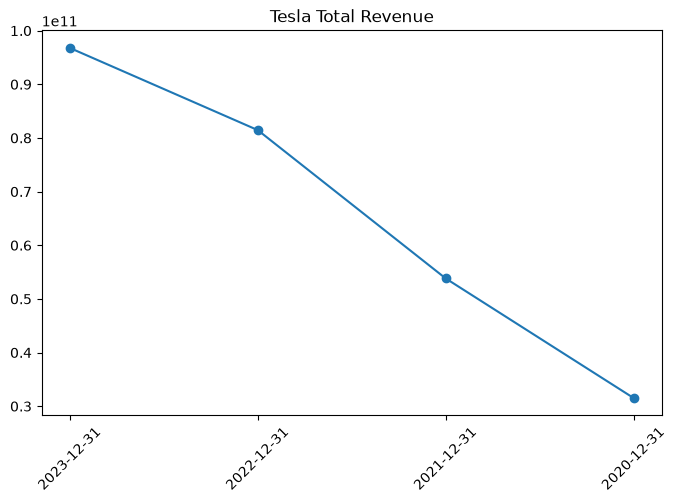

In [46]:
revenue=financial[financial["Metric"]=="Total Revenue"]

plt.figure(figsize=(8,5))

plt.plot(
    revenue["Year"],
    revenue["Value"],
    marker='o'
)

plt.title("Tesla Total Revenue")

plt.xticks(rotation=45)
plt.show()

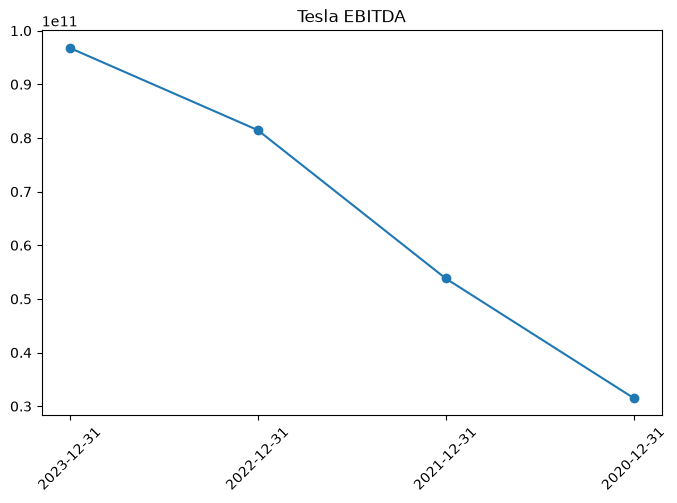

In [47]:
ebitda=financial[
    financial["Metric"]=="EBITDA"
]

plt.figure(figsize=(8,5))

plt.plot(
    revenue["Year"],
    revenue["Value"],
    marker='o'
)

plt.title("Tesla EBITDA")

plt.xticks(rotation=45)
plt.show()

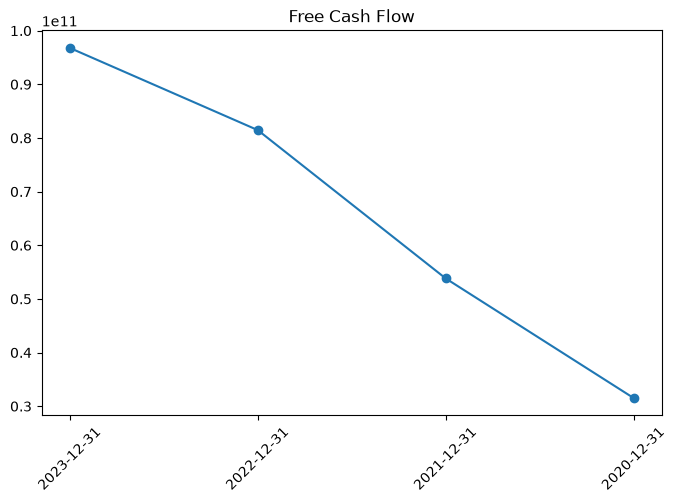

In [48]:
fcf=cash[
    cash["Metric"]=="Free Cash Flow"
]
plt.figure(figsize=(8,5))

plt.plot(
    revenue["Year"],
    revenue["Value"],
    marker='o'
)

plt.title("Free Cash Flow")

plt.xticks(rotation=45)
plt.show()

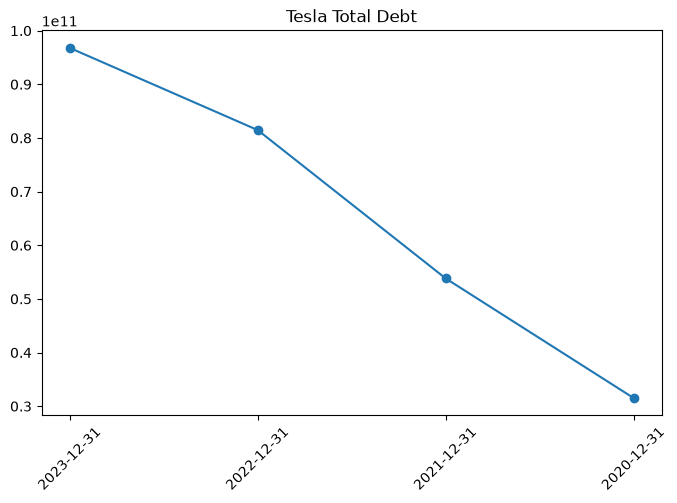

In [50]:
debt = balance[
    balance["Metric"]=="Total Debt"
]
plt.figure(figsize=(8,5))

plt.plot(
    revenue["Year"],
    revenue["Value"],
    marker='o'
)

plt.title("Tesla Total Debt")

plt.xticks(rotation=45)
plt.show()